In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(r"Desktop/ML/Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

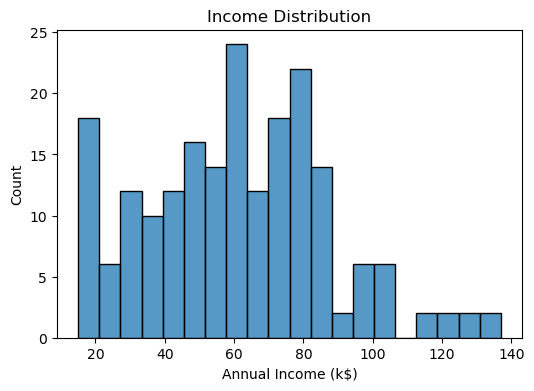

In [7]:
# Income Distribution

plt.figure(figsize=(6,4))
sns.histplot(df['Annual Income (k$)'], bins=20)
plt.title("Income Distribution")
plt.show()

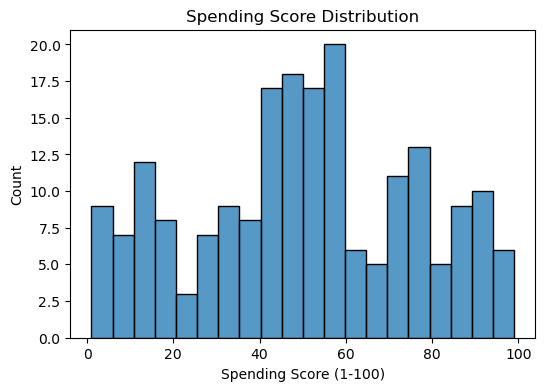

In [8]:
# Spending Score Distribution

plt.figure(figsize=(6,4))
sns.histplot(df['Spending Score (1-100)'], bins=20)
plt.title("Spending Score Distribution")
plt.show()

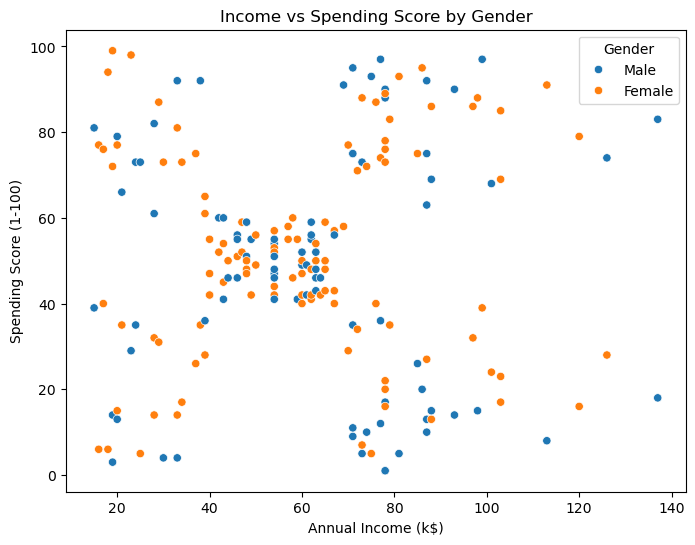

In [10]:
# Income vs Spending Scatter Plot 

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Gender'
)

plt.title("Income vs Spending Score by Gender")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.show()

### MODEL SECTION

In [14]:
# Feature Selection
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [13]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

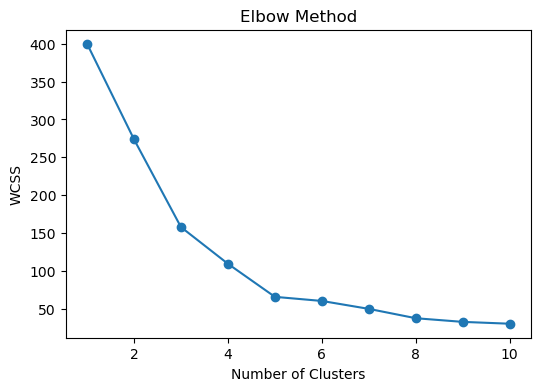

In [15]:
# Elbow Method 
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [24]:
from kneed import KneeLocator

k = range(1, 11)
knee = KneeLocator(k, wcss, curve="convex", direction="decreasing")

print("Optimal k:", knee.knee)

Optimal k: 5


In [29]:
# Apply K-Means

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_scaled)

df["Cluster"] = kmeans.labels_
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Segment
0,1,Male,19,15,39,4,Low Value
1,2,Male,21,15,81,2,Impulsive
2,3,Female,20,16,6,4,Low Value
3,4,Female,23,16,77,2,Impulsive
4,5,Female,31,17,40,4,Average


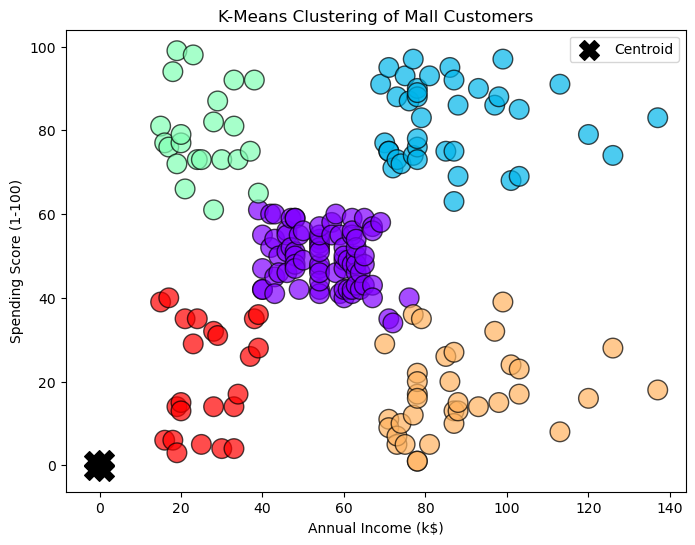

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(
    X['Annual Income (k$)'], 
    X['Spending Score (1-100)'],
    c=kmeans.labels_,
    cmap="rainbow",
    s=200,
    alpha=0.7,
    edgecolors="black"
)

plt.scatter(
    kmeans.cluster_centers_[:, 0], 
    kmeans.cluster_centers_[:, 1],
    color="black",
    marker="X",
    s=200,
    label="Centroid"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means Clustering of Mall Customers")
plt.legend()
plt.show()

In [31]:
# Cluster Analysis Table 

cluster_summary = df.groupby('Cluster')[['Annual Income (k$)','Spending Score (1-100)']].mean()
cluster_summary

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [32]:
# Label Clusters


def label_cluster(row):
    if row['Annual Income (k$)'] > 70 and row['Spending Score (1-100)'] > 70:
        return "High Value"
    elif row['Annual Income (k$)'] > 70 and row['Spending Score (1-100)'] < 40:
        return "Potential"
    elif row['Annual Income (k$)'] < 40 and row['Spending Score (1-100)'] > 60:
        return "Impulsive"
    elif row['Annual Income (k$)'] < 40 and row['Spending Score (1-100)'] < 40:
        return "Low Value"
    else:
        return "Average"

df['Segment'] = df.apply(label_cluster, axis=1)

df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Segment
0,1,Male,19,15,39,4,Low Value
1,2,Male,21,15,81,2,Impulsive
2,3,Female,20,16,6,4,Low Value
3,4,Female,23,16,77,2,Impulsive
4,5,Female,31,17,40,4,Average
...,...,...,...,...,...,...,...
195,196,Female,35,120,79,1,High Value
196,197,Female,45,126,28,3,Potential
197,198,Male,32,126,74,1,High Value
198,199,Male,32,137,18,3,Potential
